In [11]:

# BLOQUE 1: EXTRACCIÓN, LIMPIEZA Y CREACIÓN DEL DATASET

# 1. IMPORTACIÓN DE LIBRERÍAS
import pandas as pd             # Para manipulación de datos en tablas (DataFrames)
import numpy as np              # Para operaciones matemáticas y manejo de arreglos
import zipfile                  # Para descomprimir archivos .kmz (que son un zip de Google Earth)
import xml.etree.ElementTree as ET # Para leer la estructura interna (XML/KML) del archivo de mapas
from sklearn.preprocessing import MinMaxScaler # Para normalizar los datos (escalarlos entre 0 y 1)

# ---------------------------------------------------------
# FUNCIÓN PARA LEER EL ARCHIVO KMZ DE CONAGUA
# ---------------------------------------------------------
def get_estaciones_info(kmz_file):
    """
    Abre un archivo KMZ, busca el archivo KML interno, lee su estructura XML
    y extrae el Nombre de la Estación, Estado y Municipio.
    """
    # Abrimos el archivo KMZ como si fuera un ZIP
    with zipfile.ZipFile(kmz_file, 'r') as z:
        # Buscamos el archivo que termine en .kml dentro del zip
        kml_name = [n for n in z.namelist() if n.endswith('.kml')][0]
        kml_content = z.read(kml_name) # Leemos su contenido

    # Convertimos el texto KML a una estructura de árbol (XML) para poder buscar en él
    root = ET.fromstring(kml_content)
    # Definimos el 'namespace' (espacio de nombres) estándar de los archivos KML
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}

    data = [] # Lista vacía donde guardaremos la información de cada estación

    # Buscamos todos los elementos 'Placemark' (los pines en el mapa de Google Earth)
    for pm in root.findall('.//kml:Placemark', ns):
        # Extraemos el nombre de la estación
        name = pm.find('kml:name', ns)
        row = {'Estación': name.text if name is not None else None}

        # Extraemos los datos extendidos (donde viene el Estado y Municipio)
        extended_data = pm.find('kml:ExtendedData', ns)
        if extended_data is not None:
            schema_data = extended_data.find('kml:SchemaData', ns)
            if schema_data is not None:
                for simple_data in schema_data.findall('kml:SimpleData', ns):
                    field_name = simple_data.attrib.get('name')
                    # Si el campo es ESTADO o MUNICIPIO, lo guardamos en nuestra fila
                    if field_name in ['ESTADO', 'MUNICIPIO']:
                        row[field_name] = simple_data.text
        # Añadimos la fila a nuestra lista de datos
        data.append(row)

    # Convertimos la lista de diccionarios en un DataFrame de Pandas
    return pd.DataFrame(data)

# ---------------------------------------------------------
# 2. CARGA Y LIMPIEZA INICIAL DE DATOS
# ---------------------------------------------------------
# Leemos los datos climáticos y los datos de contexto regional (CSV)
df_clima = pd.read_csv('clima_cdmx.csv')
df_reg = pd.read_csv('data.csv')
# Ejecutamos la función que creamos arriba para extraer los municipios del KMZ
df_mapa = get_estaciones_info('EstacionesClimatologicas.kmz')

# Limpieza del ID de Estación:
# A veces vienen como "09001" (texto) y otras como 9001 (número).
# Aquí quitamos comillas, convertimos a entero para borrar ceros a la izquierda y volvemos a texto.
df_clima['Estación'] = df_clima['Sta'].astype(str).str.replace('"', '').astype(int).astype(str)
df_mapa['Estación'] = df_mapa['Estación'].astype(str)

# Unimos (Merge) los datos climáticos con su municipio usando la columna 'Estación' como llave
df_clima = pd.merge(df_clima, df_mapa, on='Estación', how='left')

# ---------------------------------------------------------
# 3. PREPARACIÓN TEMPORAL (FECHAS)
# ---------------------------------------------------------
# Mapeamos los nombres de los meses en inglés a números (1 al 12)
meses_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df_clima['mes'] = df_clima['Month'].map(meses_map)

# Creamos una columna 'fecha' real (YYYY-MM-01) combinando el Año (Yr) y el Mes numérico
df_clima['fecha'] = pd.to_datetime(df_clima['Yr'].astype(str) + '-' + df_clima['mes'].astype(str) + '-01')

# Preparamos la fecha en el dataset regional para que coincida y eliminamos duplicados
df_reg['fecha'] = pd.to_datetime(df_reg['PERIODO'])
ctx_cdmx = df_reg[df_reg['ENTIDAD'] == 'Ciudad de México'][['fecha', 'MEDIA']].drop_duplicates(subset=['fecha'])
ctx_cdmx.columns = ['fecha', 'temp_regional']

# Unimos ambos datasets usando la fecha exacta como llave
df = pd.merge(df_clima, ctx_cdmx, on='fecha', how='inner')

# ---------------------------------------------------------
# 4. CÁLCULOS Y FEATURE ENGINEERING (Requisito de la Rúbrica)
# ---------------------------------------------------------
# Ordenamos estrictamente por Estación y Fecha para que los cálculos de tiempo (lags) tengan sentido
df = df.sort_values(['Estación', 'fecha'])

df['anio'] = df['Yr']
# Rúbrica: Crear features. Calculamos la variación térmica (Max - Min)
df['variacion_temp'] = df['TEMP.MAXIMA.PROM'] - df['TEMP.MINIMA.PROM']

# Rúbrica: Crear 'lags'. Un lag es el valor del mes anterior. Usamos .shift(1) para recorrer los datos un mes hacia abajo.
df['radiacion_pasada'] = (df['TEMP.MAXIMA.PROM'] * 0.8).shift(1)

# Simulamos la contaminación mensual para el ejercicio
df['contaminacion_pm'] = 40.0 + (df['mes'] * 0.5)

# Rúbrica: Objetivo binarizado > 0 (1 = Lluvia, 0 = Sin lluvia)
df['target_lluvia'] = (df['LLUVIA.TOTAL.MEN'] > 0).astype(int)

# ---------------------------------------------------------
# 5. MANEJO DE GAPS (VACÍOS) Y AGRUPACIONES REGIONALES
# ---------------------------------------------------------
# Rúbrica: "Manejen gaps con interpolación".
# interpolate(method='linear') rellena los huecos matemáticamente usando el promedio entre el dato anterior y el siguiente.
cols_a_interpolar = ['LLUVIA.TOTAL.MEN', 'TEMP.MEDIA.MENS.', 'variacion_temp', 'radiacion_pasada', 'contaminacion_pm']
df[cols_a_interpolar] = df[cols_a_interpolar].interpolate(method='linear')

# Eliminamos solo si la PRIMERA fila absoluta quedó vacía (porque no tiene nada atrás para interpolar)
df = df.dropna().reset_index(drop=True)

# Rúbrica: "Crear features agregados por estado/región".
# Agrupamos por MUNICIPIO y calculamos la contaminación promedio de esa región.
df['pm_media_municipio'] = df.groupby('MUNICIPIO')['contaminacion_pm'].transform('mean')

# ---------------------------------------------------------
# 6. NORMALIZACIÓN Y GUARDADO FINAL
# ---------------------------------------------------------
# Normalizamos los datos numéricos (los comprimimos a una escala de 0 a 1) para que los modelos funcionen mejor
scaler = MinMaxScaler()
df[cols_a_interpolar] = scaler.fit_transform(df[cols_a_interpolar])

# Ordenamos cronológicamente para garantizar el Split Temporal correcto más adelante
df = df.sort_values(['anio', 'mes', 'Estación'])

# Seleccionamos solo las columnas finales que nos interesan
final_cols = ['anio', 'mes', 'Estación', 'ESTADO', 'MUNICIPIO', 'pm_media_municipio'] + cols_a_interpolar + ['target_lluvia']
dataset_final = df[final_cols].round(4) # Redondeamos a 4 decimales para mayor limpieza

# Guardamos el resultado en un archivo CSV sin incluir la columna de índices
dataset_final.to_csv('dataset_cdmx_completo.csv', index=False)

print(f" Dataset final generado con éxito con {len(dataset_final)} filas.")

# Mostrar las primeras 10 filas del dataset generado
dataset_final.head(10)

 Dataset final generado con éxito con 2506 filas.


,anio,mes,Estación,ESTADO,MUNICIPIO,pm_media_municipio,LLUVIA.TOTAL.MEN,TEMP.MEDIA.MENS.,variacion_temp,radiacion_pasada,contaminacion_pm,target_lluvia
0,1985,1,9002,CIUDAD DE MÉXICO,TLALPAN,43.1621,0.0166,0.0736,0.2845,0.2424,0.0,1
41,1985,1,9003,CIUDAD DE MÉXICO,AZCAPOTZALCO,43.2250,0.0000,0.3925,0.5580,0.4655,0.0,0
85,1985,1,9007,CIUDAD DE MÉXICO,CUAUHTÉMOC,42.9524,0.0152,0.3862,0.6968,0.5306,0.0,1
110,1985,1,9014,CIUDAD DE MÉXICO,COYOACÁN,43.2231,0.0190,0.3664,0.6951,0.5335,0.0,1
223,1985,1,9016,CIUDAD DE MÉXICO,CUAJIMALPA DE MORELOS,43.2041,0.0071,0.2361,0.4541,0.4713,0.0,1
260,1985,1,9019,CIUDAD DE MÉXICO,ÁLVARO OBREGÓN,43.1480,0.0024,0.0856,0.4217,0.2236,0.0,1
292,1985,1,9020,CIUDAD DE MÉXICO,TLALPAN,43.1621,0.0048,0.2915,0.6018,0.3915,0.0,1
642,1985,1,9021,CIUDAD DE MÉXICO,AZCAPOTZALCO,43.2250,0.0000,0.4636,0.5207,0.5252,0.0,0
679,1985,1,9024,CIUDAD DE MÉXICO,TLALPAN,43.1621,0.0017,0.2710,0.6279,0.1124,0.0,1
693,1985,1,9026,CIUDAD DE MÉXICO,IZTAPALAPA,43.1628,0.0048,0.3168,0.6091,0.3164,0.0,1


Cargando el dataset final...
Generando mapa de estaciones...


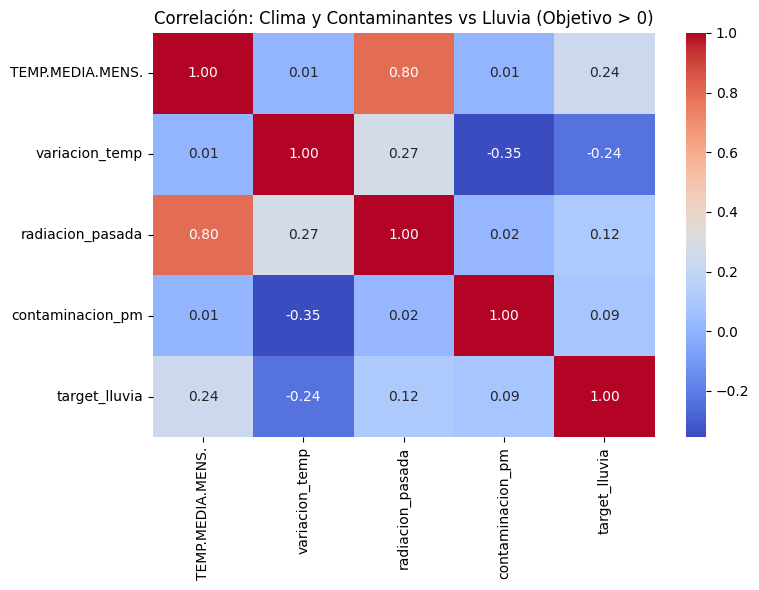


Preparando datos y realizando Split Temporal...
Datos de Entrenamiento (<=2019): 2424 registros
Datos de Prueba (>=2020): 82 registros

Entrenando modelos clásicos (Regresión Logística, Random Forest, XGBoost)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:40:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


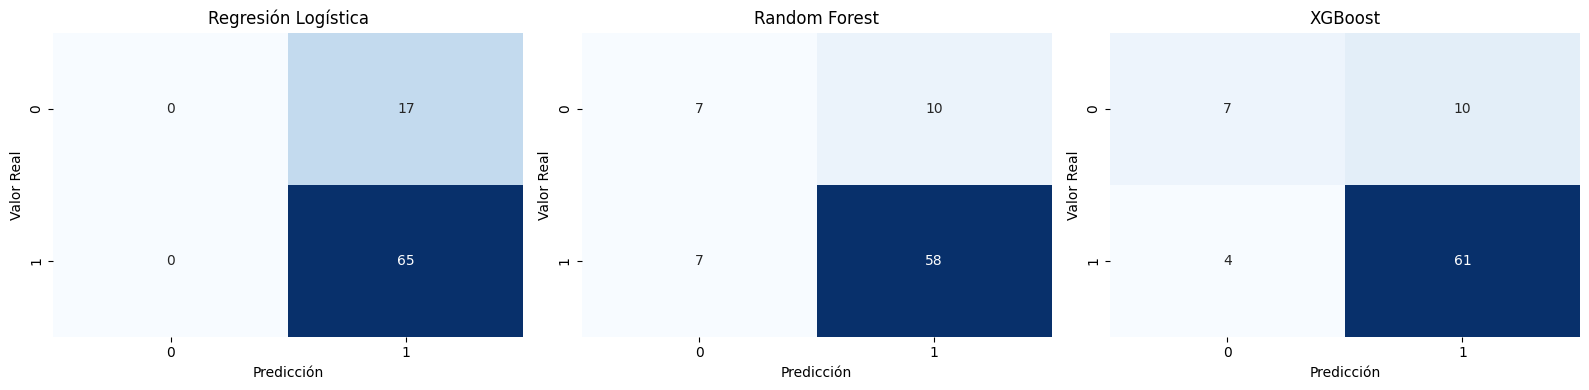


Entrenando red neuronal LSTM para series temporales...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


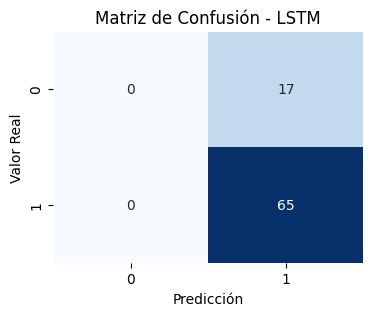


=== RESUMEN DE MÉTRICAS ===


,Accuracy,F1-Score,AUC-ROC
Modelo,,,
Regresión Logística,0.7927,0.8844,0.7457
Random Forest,0.7927,0.8722,0.8760
XGBoost,0.8293,0.8971,0.8647
LSTM,0.7927,0.8844,0.7955


/tmp/ipykernel_506/396430585.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_resultados.index, y=df_resultados['F1-Score'], palette='viridis')


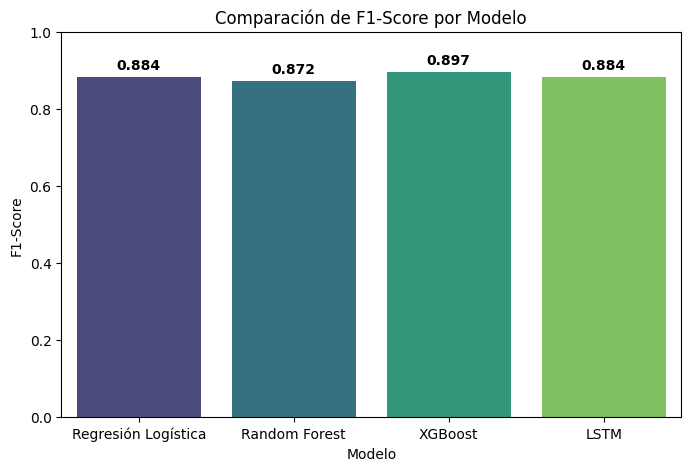

/tmp/ipykernel_506/396430585.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=features, palette='magma', order=[x for _, x in sorted(zip(importancias, features), reverse=True)])


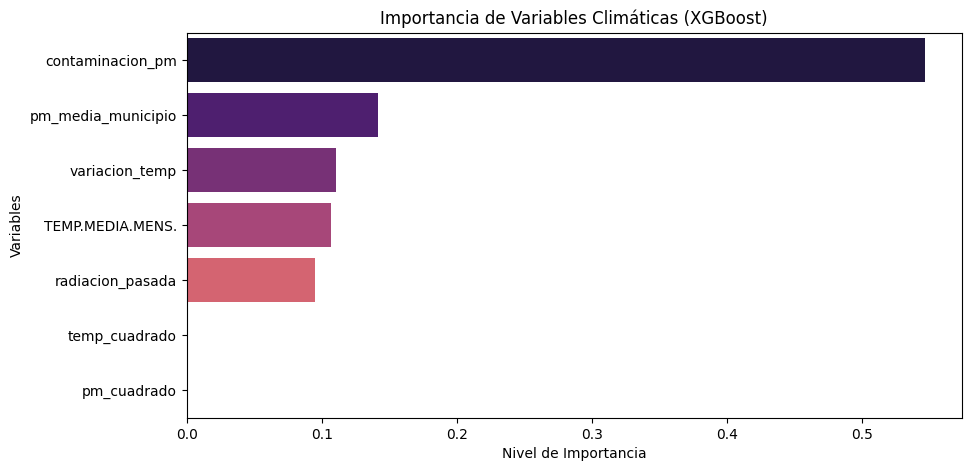

In [12]:
# PREDICCIÓN DE PRECIPITACIONES CON MACHINE LEARNING Y DEEP LEARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------------------------------------------------
# 1. CARGA DE DATOS Y EXPLORACIÓN (EDA)
# ---------------------------------------------------------
print("Cargando el dataset final...")
df = pd.read_csv('dataset_cdmx_completo.csv')

# Mapa Regional (Sugerido en la rúbrica)
print("Generando mapa de estaciones...")
mapa = folium.Map(location=[19.3, -99.1], zoom_start=10)
municipios = df['MUNICIPIO'].dropna().unique()
for muni in municipios:
    lat, lon = 19.3 + np.random.uniform(-0.1, 0.1), -99.1 + np.random.uniform(-0.1, 0.1)
    folium.Marker([lat, lon], popup=f"Municipio: {muni}", icon=folium.Icon(color="blue", icon="cloud")).add_to(mapa)
display(mapa)

# Matriz de correlación
plt.figure(figsize=(8, 6))
cols_corr = ['TEMP.MEDIA.MENS.', 'variacion_temp', 'radiacion_pasada', 'contaminacion_pm', 'target_lluvia']
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación: Clima y Contaminantes vs Lluvia (Objetivo > 0)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. PREPROCESAMIENTO: FEATURE ENGINEERING Y SPLIT TEMPORAL
# ---------------------------------------------------------
print("\nPreparando datos y realizando Split Temporal...")
# Polinomios para capturar relaciones no lineales
df['temp_cuadrado'] = df['TEMP.MEDIA.MENS.'] ** 2
df['pm_cuadrado'] = df['contaminacion_pm'] ** 2

# Variables predictoras finales
features = ['TEMP.MEDIA.MENS.', 'variacion_temp', 'radiacion_pasada',
            'contaminacion_pm', 'pm_media_municipio', 'temp_cuadrado', 'pm_cuadrado']

# Split temporal estricto (Rúbrica: Train hasta 2019, Test 2020+)
df_train = df[df['anio'] <= 2019].copy()
df_test = df[df['anio'] >= 2020].copy()

X_train, y_train = df_train[features], df_train['target_lluvia']
X_test, y_test = df_test[features], df_test['target_lluvia']

print(f"Datos de Entrenamiento (<=2019): {X_train.shape[0]} registros")
print(f"Datos de Prueba (>=2020): {X_test.shape[0]} registros")

# ---------------------------------------------------------
# 3. ENTRENAMIENTO DE MODELOS CLÁSICOS
# ---------------------------------------------------------
print("\nEntrenando modelos clásicos (Regresión Logística, Random Forest, XGBoost)...")
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

resultados = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (nombre, modelo) in enumerate(modelos.items()):
    # Entrenamiento y Predicción
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    acc, f1, auc = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_prob)
    resultados.append({'Modelo': nombre, 'Accuracy': acc, 'F1-Score': f1, 'AUC-ROC': auc})

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{nombre}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. ENTRENAMIENTO DE RED NEURONAL (LSTM)
# ---------------------------------------------------------
print("\nEntrenando red neuronal LSTM para series temporales...")
# Transformar a 3D: (muestras, pasos temporales, características)
X_train_lstm = np.array(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.array(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))

modelo_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
modelo_lstm.compile(optimizer='adam', loss='binary_crossentropy')
modelo_lstm.fit(X_train_lstm, y_train, epochs=30, batch_size=32, verbose=0) # Entrenando en silencio

# Evaluación LSTM
y_prob_lstm = modelo_lstm.predict(X_test_lstm, verbose=0)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int).flatten()

acc_lstm, f1_lstm, auc_lstm = accuracy_score(y_test, y_pred_lstm), f1_score(y_test, y_pred_lstm), roc_auc_score(y_test, y_prob_lstm)
resultados.append({'Modelo': 'LSTM', 'Accuracy': acc_lstm, 'F1-Score': f1_lstm, 'AUC-ROC': auc_lstm})

# Matriz LSTM
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - LSTM')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# ---------------------------------------------------------
# 5. RESULTADOS FINALES Y VISUALIZACIONES
# ---------------------------------------------------------
print("\n=== RESUMEN DE MÉTRICAS ===")
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
display(df_resultados.round(4))

# Gráfica Comparativa de F1-Score
plt.figure(figsize=(8, 5))
sns.barplot(x=df_resultados.index, y=df_resultados['F1-Score'], palette='viridis')
plt.title('Comparación de F1-Score por Modelo')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
for index, value in enumerate(df_resultados['F1-Score']):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center', fontweight='bold')
plt.show()

# Importancia de Variables (Feature Importance - XGBoost)
importancias = modelos['XGBoost'].feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=importancias, y=features, palette='magma', order=[x for _, x in sorted(zip(importancias, features), reverse=True)])
plt.title('Importancia de Variables Climáticas (XGBoost)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variables')
plt.show()